# Digital Filtering Design – FIR and IIR
This notebook demonstrates basic filter design and application to noisy signals.

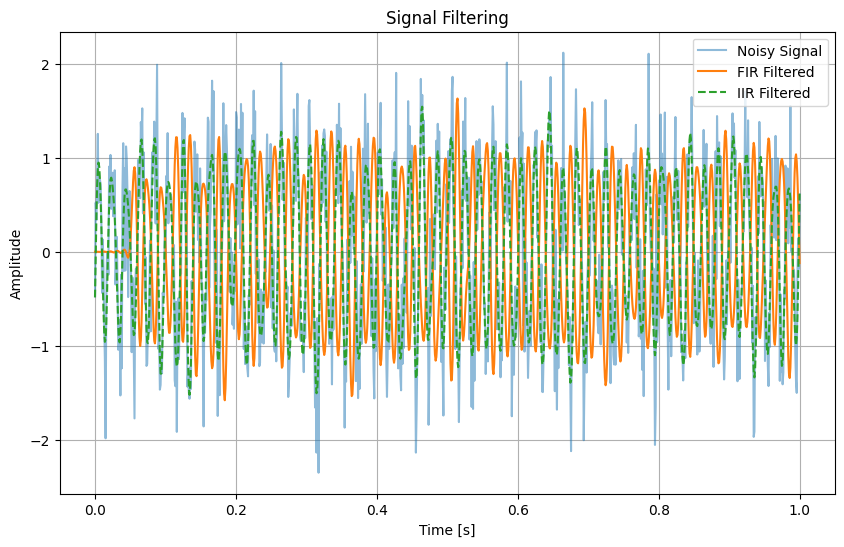

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.io import wavfile

# Generate a noisy signal
fs = 1000  # Sampling frequency
t = np.linspace(0, 1.0, fs)
sig = np.sin(2 * np.pi * 50 * t) + np.random.normal(0, 0.5, fs)

# FIR filter
numtaps = 101
cutoff = 100
fir = signal.firwin(numtaps, cutoff, fs=fs)
filtered_fir = signal.lfilter(fir, 1.0, sig)

# IIR filter
b, a = signal.butter(4, 100, fs=fs, btype='low')
filtered_iir = signal.filtfilt(b, a, sig)

# Plot results
plt.figure(figsize=(10, 6))
plt.plot(t, sig, label='Noisy Signal', alpha=0.5)
plt.plot(t, filtered_fir, label='FIR Filtered')
plt.plot(t, filtered_iir, label='IIR Filtered', linestyle='--')
plt.legend()
plt.title('Signal Filtering')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()